In [23]:
import os
import numpy as np
import pandas as pd
from tqdm import tqdm
import seaborn as sns
from sklearn.svm import SVC
from itertools import product
from sklearn.base import clone
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.decomposition import PCA
from joblib import Parallel, delayed
from scipy.stats import randint, uniform
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.model_selection import KFold, cross_val_score
from sklearn.base import clone
from sklearn.model_selection import train_test_split, RandomizedSearchCV, KFold
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix
)

# Multi-Model Random Search – Explained Steps :

## 1. **Load Train & Test Data**

* Read `train.csv`,`val.csv` and `test.csv` using pandas.
* These already have features and a label column (e.g., `"protein_name"`).

## 2. **Encode Labels**

* Convert `protein_name` (text labels) into numeric labels using `LabelEncoder`.
* This is required because machine learning models need numbers, not strings.

## 3. **Prepare Features and Labels**

* Remove unnecessary columns like:

  * `uniprot_id` and `protein_name` (identifiers)
  * `label_column` (temporarily moved to `y`)

* Split the data into:

  * `X_train`, `y_train` for training (from train data)
  * `X_test`, `y_test` for testing (from val data)

## 4. **Define Models**

* Set up 2 classifiers:

  * `RandomForestClassifier`
  * `AdaBoostClassifier`

## 5. **Define Hyperparameter Search Space**

* Create a different set of hyperparameter options for each model.
* Use `randint` and `uniform` to generate random values within a range.
* These will be sampled during random search.

## 6. **Run Randomized Search**

* For each model:

  * Perform `RandomizedSearchCV` with:

    * The model
    * Its parameter space
    * `n_iter` (how many random combos to try)
    * Cross-validation (`cv`)
    * Scoring metric (`accuracy`)
  * Train it and evaluate on test set.
  * Print accuracy and classification report.

## 7. **Store Results**

* Save the best model, accuracy, parameters, and full report for each model.
* Use a dictionary called `self.results`.

## 8. **Select the Best Model**

* Pick the model with the highest test accuracy.
* Save it as `self.best_model` and its name.

## 9. **Get the Best Model**

* Use `get_best_model()` to return the top model and its name for later use (e.g., saving or inference).

In [24]:
class MultiModelRandomSearch:
    def __init__(self, train_df: pd.DataFrame, test_df: pd.DataFrame, label_column: str):
        self.label_column = label_column

        self.label_encoder = LabelEncoder()
        train_df[label_column] = self.label_encoder.fit_transform(train_df[label_column])
        test_df[label_column] = self.label_encoder.transform(test_df[label_column])

        drop_cols = [label_column, "uniprot_id", "protein_name", "fold"]
        self.X_train = train_df.drop(columns=[col for col in drop_cols if col in train_df.columns])
        self.y_train = train_df[label_column]

        self.X_test = test_df.drop(columns=[col for col in drop_cols if col in test_df.columns])
        self.y_test = test_df[label_column]

        self.models = {
            "RandomForest": RandomForestClassifier(random_state=42),
            "AdaBoost": AdaBoostClassifier(random_state=42)
        }

        self.param_distributions = {
            "RandomForest": {
                "n_estimators": randint(100, 300),
                "max_depth": [None, 10, 20, 30],
                "min_samples_split": randint(2, 10),
                "min_samples_leaf": randint(1, 5),
                "bootstrap": [True, False]
            },
            "AdaBoost": {
                "n_estimators": randint(50, 150),
                "learning_rate": uniform(0.1, 1.0)
            }
        }

        self.results = dict()
        self.best_model = None
        self.best_model_name = ""

    def run_random_search(self, n_iter=20, cv=5, scoring='accuracy', n_jobs=-1):
        for name, model in self.models.items():
            print(f"\nRunning RandomizedSearchCV for {name}...")

            random_search = RandomizedSearchCV(
                estimator=model,
                param_distributions=self.param_distributions[name],
                n_iter=n_iter,
                cv=cv,
                scoring=scoring,
                n_jobs=n_jobs,
                random_state=42,
                verbose=1
            )

            random_search.fit(self.X_train, self.y_train)

            best_model = random_search.best_estimator_
            best_params = random_search.best_params_
            y_pred = best_model.predict(self.X_test)
            acc = accuracy_score(self.y_test, y_pred)

            print(f"{name} - Accuracy: {acc:.4f}")
            print(f"Best Params: {best_params}")
            print("\nClassification Report:\n", classification_report(self.y_test, y_pred))

            self.results[name] = {
                "model": best_model,
                "accuracy": acc,
                "params": best_params,
                "report": classification_report(self.y_test, y_pred, output_dict=True)
            }

        self.best_model_name = max(self.results, key=lambda k: self.results[k]["accuracy"])
        self.best_model = self.results[self.best_model_name]["model"]

        print(f"\nBest Model: {self.best_model_name} with accuracy {self.results[self.best_model_name]['accuracy']:.4f}")

    def get_best_model(self):
        return self.best_model, self.best_model_name

if __name__ == "__main__":
    train_df = pd.read_csv("../processed_data/Split data/train_dd.csv")
    val_df = pd.read_csv("../processed_data/Split data/val_dd.csv")
    test_df = pd.read_csv("../processed_data/Split data/test_dd.csv")

    selector = MultiModelRandomSearch(
        train_df=train_df,
        test_df=val_df, #taking validation set to find the best model
        label_column="protein_name"
    )

    selector.run_random_search(n_iter=25)
    best_model, name = selector.get_best_model()


Running RandomizedSearchCV for RandomForest...
Fitting 5 folds for each of 25 candidates, totalling 125 fits
RandomForest - Accuracy: 0.7371
Best Params: {'bootstrap': False, 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 8, 'n_estimators': 221}

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        35
           1       0.12      0.14      0.13        22
           2       0.80      1.00      0.89        47
           3       0.45      0.37      0.41        38
           4       0.95      0.72      0.82        29
           5       1.00      1.00      1.00        23

    accuracy                           0.74       194
   macro avg       0.72      0.70      0.71       194
weighted avg       0.74      0.74      0.73       194


Running RandomizedSearchCV for AdaBoost...
Fitting 5 folds for each of 25 candidates, totalling 125 fits
AdaBoost - Accuracy: 0.7165
Best Params: {'learning_rate': 1.07

# Final Model Evaluation

## 1. **Load Everything**

* Read the train, validation and test data. combine the train and validation dataset to make a new train data for k-folding.
* Get the best model, Random Forest (already trained) from the previous random search.

## 2. **Set Up Evaluator**

* Create `FinalModelEvaluator` with:

  * The best model
  * The full dataset
  * Label column name (`protein_name`)
  * Number of folds for cross-validation (`n_splits=10`)

## 3. **Prepare Data**

* Split the data into:

  * `X`: All features
  * `y`: The label column
* Set up `KFold` for splitting into `n_splits` folds with shuffling.

## 4. **Run Cross-Validation**

For each fold:

* Train the model on training part with combined trained data.
* Predict on testing part.
* Generate Confusion Matrix.
* Calculate and store:

  * Accuracy
  * Precision
  * Recall
  * F1-score
  * ROC AUC

## 5. **Print Final Results**

* For each metric:

  * Print **mean ± std** across all folds.


In [26]:
class FinalModelEvaluator:
    def __init__(self, train_df, val_df, test_df, model_params, label_column):
        self.label_column = label_column
        self.label_encoder = LabelEncoder()

        # Combine training and validation sets
        self.train_df = pd.concat([train_df, val_df], ignore_index=True)
        self.test_df = test_df.copy()

        # Encode labels from 0 to 5
        self.train_df[self.label_column] = self.label_encoder.fit_transform(self.train_df[self.label_column])
        self.test_df[self.label_column] = self.label_encoder.transform(self.test_df[self.label_column])

        drop_cols = [self.label_column, "uniprot_id", "protein_name", "fold"]
        self.X_train = self.train_df.drop(columns=[col for col in drop_cols if col in self.train_df.columns])
        self.y_train = self.train_df[self.label_column]

        self.X_test = self.test_df.drop(columns=[col for col in drop_cols if col in self.test_df.columns])
        self.y_test = self.test_df[self.label_column]

        # Instantiate model with provided parameters
        self.model = RandomForestClassifier(**model_params, random_state=42)

    def evaluate_model(self):
        print("Starting 5-Fold Cross-Validation...\n")
        cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

        scoring_metrics = ['accuracy', 'precision_weighted', 'recall_weighted', 'f1_weighted', 'roc_auc_ovr']

        cv_results = cross_validate(
            estimator=self.model,
            X=self.X_train,
            y=self.y_train,
            cv=cv,
            scoring=scoring_metrics,
            return_train_score=False
        )

        for metric in scoring_metrics:
            print(f"{metric}: {cv_results[f'test_{metric}'].mean():.4f} ± {cv_results[f'test_{metric}'].std():.4f}")
            
        self.model.fit(self.X_train, self.y_train)
        y_pred = self.model.predict(self.X_test)

        print("\nEvaluating on Test Set:")
        print(f"Accuracy: {accuracy_score(self.y_test, y_pred):.4f}")
        print(f"Precision: {precision_score(self.y_test, y_pred, average='weighted'):.4f}")
        print(f"Recall: {recall_score(self.y_test, y_pred, average='weighted'):.4f}")
        print(f"F1 Score: {f1_score(self.y_test, y_pred, average='weighted'):.4f}")
        
        try:
            roc_auc = roc_auc_score(self.y_test, self.model.predict_proba(self.X_test), multi_class='ovr')
            print(f"ROC-AUC Score (OVR): {roc_auc:.4f}")
        except Exception as e:
            print("ROC-AUC calculation failed:", str(e))

        # Confusion Matrix
        cm = confusion_matrix(self.y_test, y_pred, labels=range(6))
        plt.figure(figsize=(8, 6))
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", 
                    xticklabels=range(6), yticklabels=range(6))
        plt.xlabel("Predicted Class")
        plt.ylabel("True Class")
        plt.title("Confusion Matrix - Test Set")
        plt.tight_layout()
        plt.show()

Starting 5-Fold Cross-Validation...

accuracy: 0.7812 ± 0.0038
precision_weighted: 0.7637 ± 0.0100
recall_weighted: 0.7812 ± 0.0038
f1_weighted: 0.7698 ± 0.0058
roc_auc_ovr: 0.9110 ± 0.0050

Evaluating on Test Set:
Accuracy: 0.7617
Precision: 0.7564
Recall: 0.7617
F1 Score: 0.7568
ROC-AUC Score (OVR): 0.8961


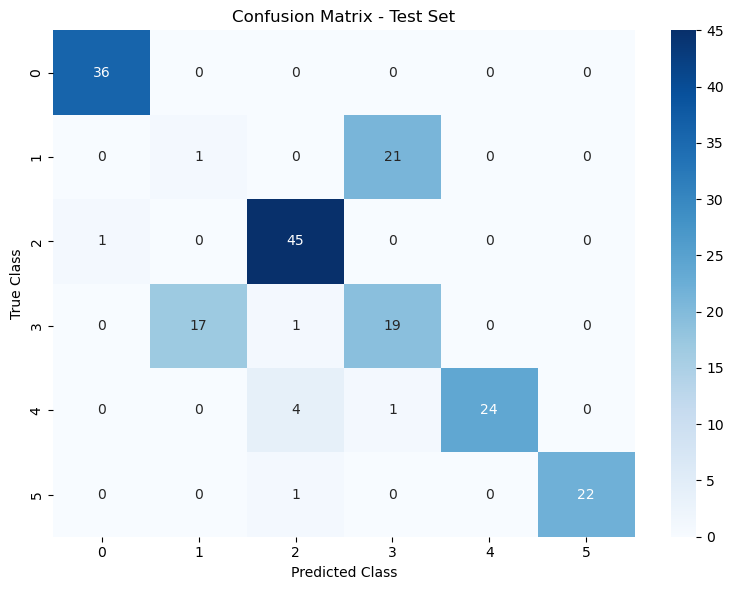

In [27]:
if __name__ == "__main__":
    # Load data
    train_df = pd.read_csv("../processed_data/Split data/train_dd.csv")
    val_df = pd.read_csv("../processed_data/Split data/val_dd.csv")
    test_df = pd.read_csv("../processed_data/Split data/test_dd.csv")

    # Best parameters found earlier
    best_rf_params = {
        "bootstrap": False,
        "max_depth": None,
        "min_samples_leaf": 1,
        "min_samples_split": 8,
        "n_estimators": 221
    }

    # Evaluate model
    evaluator = FinalModelEvaluator(
        train_df=train_df,
        val_df=val_df,
        test_df=test_df,
        model_params=best_rf_params,
        label_column="protein_name"
    )

    evaluator.evaluate_model()